In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches

In [6]:
df = pd.read_csv('/Users/carla/Downloads/4cc07c1b-62ed-4ece-a2a4-d05d0f45081c.csv')

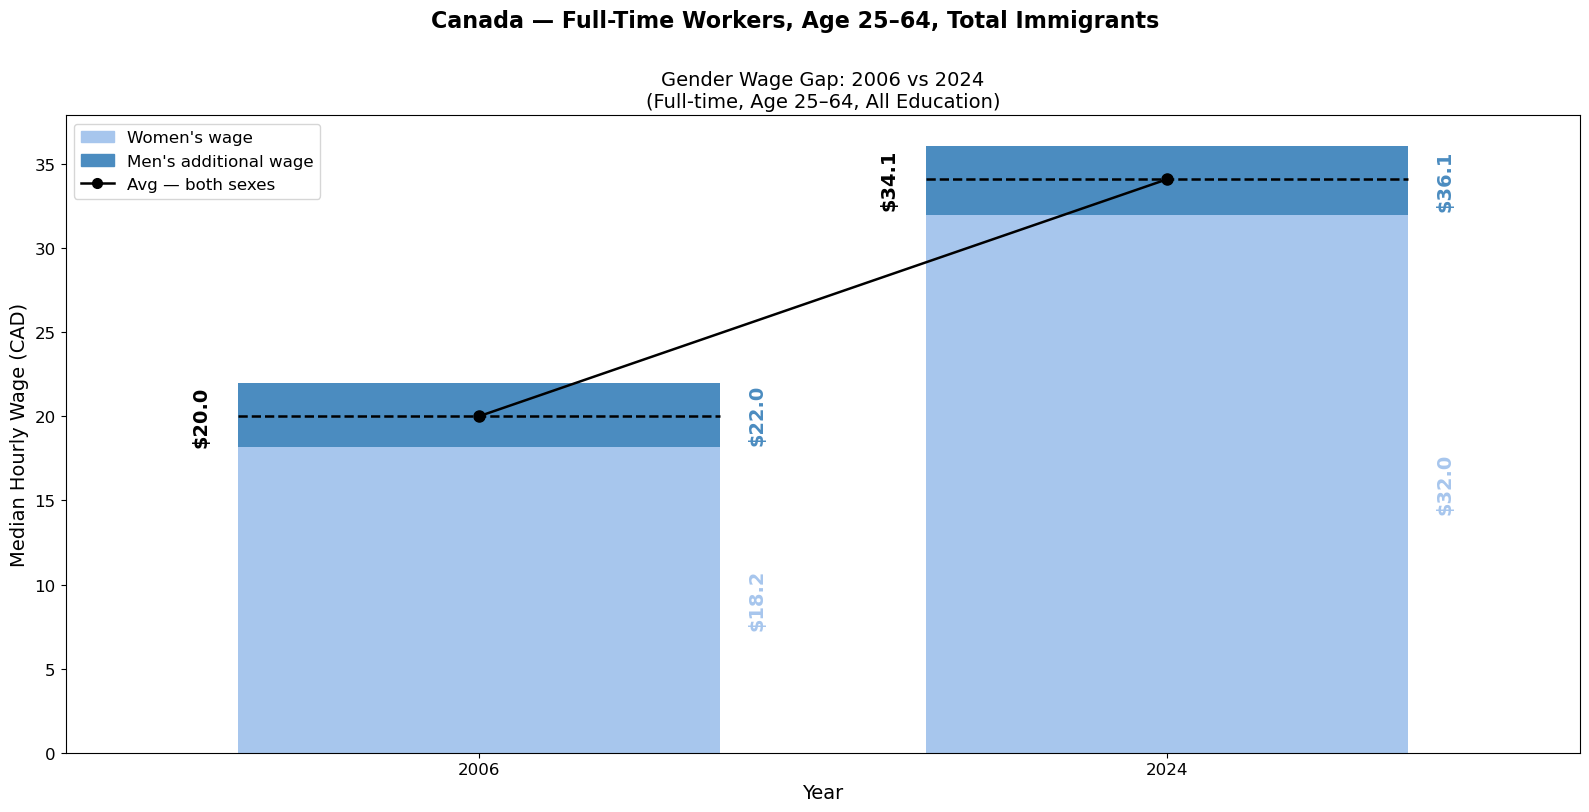

In [69]:

for col in ['GEOGRAPHY','IMMIGRANT','TYPE OF WORK','EDUCATION','AGE GROUP']:
    df[col] = df[col].str.strip()

BASE_FILTER = (df['IMMIGRANT'] == 'Total') & (df['TYPE OF WORK'] == 'Full-time') & \
              (df['AGE GROUP'] == '25 - 64') & (df['GEOGRAPHY'] == 'Canada')

EDU_LEVELS = [
    '0 - 8 years', 'High school graduate', "Bachelor's degree", "Above bachelor's degree",
]

TOTAL_EDU = 'Total, all education levels'
LINE_COLORS = ['#a8d8a2', '#a8d8a2', '#6f9f6f', '#1e3f1e']

fig, axes = plt.subplots(figsize=(16, 8))

# ── SUBPLOT 2 (right): Stacked bar — 2006 & 2024 only ──────────────────────

ax2 = axes
bar_data = df[BASE_FILTER & (df['EDUCATION'] == TOTAL_EDU) & (df['YEAR'].isin([2006, 2024]))].sort_values('YEAR')
 
years     = bar_data['YEAR'].values
women     = bar_data['Women'].values
men_extra = bar_data['Men'].values - bar_data['Women'].values
avg       = bar_data['Both sexes'].values
x = np.array([0.0, 0.5])   # closer together
width = 0.35
 
bars_w = ax2.bar(x, women,     width, color='#A7C6ED', label="Women's wage")
bars_m = ax2.bar(x, men_extra, width, bottom=women, color='#4B8CC0', label="Men's additional wage")
 
# Dashed horizontal line across each bar at avg level
for xi, a in zip(x, avg):
    ax2.hlines(a, xi - width/2, xi + width/2, colors='black', linewidth=1.8,
               linestyles='dashed', zorder=6)
    
# Black dots + connecting line
ax2.plot(x, avg, color='black', linewidth=1.8, marker='o', markersize=8,
         zorder=5, label='Avg — both sexes')


# Label women segment — rotated, on the right side of bar
for xi, w in zip(x, women):
    ax2.text(xi + width/2 + 0.02, w / 2, f'${w:.1f}', ha='left', va='center',
             fontsize=14, fontweight='bold', color='#A7C6ED', rotation=90)
 

# Label men-extra segment — rotated, on the right side of bar (total men's wage)
men_total = bar_data['Men'].values
for xi, w, me, mt in zip(x, women, men_extra, men_total):
    ax2.text(xi + width/2 + 0.02, w + me / 2, f'${mt:.1f}', ha='left', va='center',
             fontsize=14, fontweight='bold', color='#4B8CC0', rotation=90)


# Label avg — rotated, on the left side of each bar
for xi, a in zip(x, avg):
    ax2.text(xi - width/2 - 0.02, a, f'${a:.1f}', ha='right', va='center',
             fontsize=14, fontweight='bold', color='black', rotation=90)
 

ax2.set_xticks(x)
ax2.set_xticklabels(years, fontsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_xlim(-0.3, 0.8)
ax2.set_title('Gender Wage Gap: 2006 vs 2024\n(Full-time, Age 25–64, All Education)', fontsize=14)
ax2.set_xlabel('Year', fontsize=14)
ax2.set_ylabel('Median Hourly Wage (CAD)', fontsize=14)
 
women_patch = mpatches.Patch(color='#A7C6ED', label="Women's wage")
men_patch   = mpatches.Patch(color='#4B8CC0', label="Men's additional wage")
avg_marker  = plt.Line2D([0],[0], color='black', lw=1.8, marker='o', ms=7, label='Avg — both sexes')
ax2.legend(handles=[women_patch, men_patch, avg_marker], fontsize=12, loc='upper left')
 

fig.suptitle('Canada — Full-Time Workers, Age 25–64, Total Immigrants', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('/Users/carla/Documents/DSI/visualization/visualization/02_activities/assignments/assignment3_Viz2.png', dpi=150, bbox_inches='tight')
